# Replicate Signature Similarity Violins

This notebook only reads the Slurm-precomputed replicate signature outputs and plots per-condition violins for within-dataset `logFC` Spearman. Each black point is one `line + drug + dose + time` condition, red `x` markers show the same-condition baseline score, and blue/green markers show the observed mean/median.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RESULTS_DIR = Path("results/replicate_signature_similarity_sep_rep")
DATASET_ORDER = [
    "op3",
    "novartis_batch_1000",
    "vcpi_0001",
    "vcpi_0002",
    "gdpx2",
    "sciplex",
    "tahoe",
    "l1000_phase1",
    "l1000_phase2",
]
PRETTY_LABELS = {
    "op3": "OP3",
    "novartis_batch_1000": "Novartis DRUG-seq",
    "vcpi_0001": "VCPI-0001",
    "vcpi_0002": "VCPI-0002",
    "gdpx2": "GDPx2",
    "sciplex": "sci-Plex",
    "tahoe": "Tahoe-100M",
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
}

sns.set_theme(style="whitegrid", context="talk")


def pretty_label(dataset_name: str) -> str:
    return PRETTY_LABELS.get(str(dataset_name), str(dataset_name))


def dataset_label_order(frame: pd.DataFrame) -> list[str]:
    present = set(frame["dataset_name"].astype(str).unique().tolist())
    return [pretty_label(dataset_name) for dataset_name in DATASET_ORDER if dataset_name in present]


def plot_violin_with_baseline(frame: pd.DataFrame, *, observed_col: str, baseline_col: str, title: str, ylabel: str, pdf_name: str) -> pd.DataFrame:
    required_columns = {"dataset_name", "condition_key", observed_col, baseline_col}
    missing = sorted(required_columns - set(frame.columns))
    if missing:
        raise KeyError(f"Missing columns for plot {title!r}: {missing}")

    plot_frame = frame[["dataset_name", "condition_key", observed_col, baseline_col]].copy()
    plot_frame = plot_frame.rename(columns={observed_col: "observed", baseline_col: "baseline"})
    plot_frame["dataset_label"] = plot_frame["dataset_name"].map(pretty_label)
    plot_frame = plot_frame.loc[plot_frame["observed"].notna()].copy()
    if plot_frame.empty:
        raise ValueError(f"No observed values available for plot {title!r}.")

    order = dataset_label_order(plot_frame)
    fig_width = max(10.0, 1.15 * len(order) + 2.0)
    fig, ax = plt.subplots(figsize=(fig_width, 6.4))

    sns.violinplot(
        data=plot_frame,
        x="dataset_label",
        y="observed",
        order=order,
        inner=None,
        cut=0,
        linewidth=1.0,
        color="#dbe9f6",
        ax=ax,
    )

    x_lookup = {label: idx for idx, label in enumerate(order)}
    rng = np.random.default_rng(0)
    observed_x = np.array([x_lookup[label] - 0.10 for label in plot_frame["dataset_label"]], dtype=float)
    observed_x += rng.uniform(-0.08, 0.08, size=len(plot_frame))
    ax.scatter(observed_x, plot_frame["observed"], s=18, alpha=0.45, color="black", zorder=5)

    baseline_frame = plot_frame.loc[plot_frame["baseline"].notna()].copy()
    baseline_count_by_dataset = baseline_frame.groupby("dataset_name")["condition_key"].nunique() if not baseline_frame.empty else pd.Series(dtype=int)
    if not baseline_frame.empty:
        baseline_x = np.array([x_lookup[label] + 0.17 for label in baseline_frame["dataset_label"]], dtype=float)
        baseline_x += rng.uniform(-0.04, 0.04, size=len(baseline_frame))
        ax.scatter(
            baseline_x,
            baseline_frame["baseline"],
            s=42,
            alpha=0.95,
            marker="x",
            linewidths=1.5,
            color="#c83e4d",
            zorder=6,
        )

    summary = (
        plot_frame.groupby(["dataset_name", "dataset_label"], as_index=False)
        .agg(
            n_conditions=("condition_key", "nunique"),
            observed_mean=("observed", "mean"),
            observed_median=("observed", "median"),
            baseline_mean=("baseline", "mean"),
            baseline_median=("baseline", "median"),
        )
        .sort_values(by="dataset_name", key=lambda s: s.map({name: idx for idx, name in enumerate(DATASET_ORDER)}))
        .reset_index(drop=True)
    )
    summary["n_conditions_with_baseline"] = summary["dataset_name"].map(baseline_count_by_dataset).fillna(0).astype(int)

    for _, row in summary.iterrows():
        x = x_lookup[row["dataset_label"]]
        if pd.notna(row["observed_mean"]):
            ax.scatter(x - 0.16, row["observed_mean"], marker="D", s=62, color="#1f77b4", zorder=7)
        if pd.notna(row["observed_median"]):
            ax.scatter(x - 0.16, row["observed_median"], marker="s", s=58, color="#2ca02c", zorder=7)
        if pd.notna(row["baseline_mean"]):
            ax.scatter(x + 0.23, row["baseline_mean"], marker="^", s=68, color="#c83e4d", zorder=7)

    handles = [
        Line2D([], [], linestyle="", marker="o", color="black", markersize=5, alpha=0.6, label="Observed condition"),
        Line2D([], [], linestyle="", marker="x", color="#c83e4d", markersize=7, label="Baseline condition"),
        Line2D([], [], linestyle="", marker="D", color="#1f77b4", markersize=7, label="Observed mean"),
        Line2D([], [], linestyle="", marker="s", color="#2ca02c", markersize=7, label="Observed median"),
        Line2D([], [], linestyle="", marker="^", color="#c83e4d", markersize=7, label="Baseline mean"),
    ]
    ax.legend(handles=handles, loc="best", frameon=True)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=35)
    sns.despine(ax=ax)
    fig.tight_layout()
    out_path = RESULTS_DIR / pdf_name
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out_path}")
    zero_baseline = summary.loc[summary["n_conditions_with_baseline"] == 0, "dataset_label"].tolist()
    if zero_baseline:
        print("No baseline-scored conditions in:", ", ".join(zero_baseline))
    display(summary)
    return summary


def plot_summary_heatmap(summary: pd.DataFrame, *, title: str, value_label: str, pdf_name: str) -> pd.DataFrame:
    required_columns = {"dataset_name", "dataset_label", "observed_mean", "baseline_mean"}
    missing = sorted(required_columns - set(summary.columns))
    if missing:
        raise KeyError(f"Missing columns for heatmap {title!r}: {missing}")

    summary_frame = summary.copy()
    summary_frame["delta_mean"] = summary_frame["observed_mean"] - summary_frame["baseline_mean"]
    dataset_order_map = {name: idx for idx, name in enumerate(DATASET_ORDER)}
    summary_frame = summary_frame.sort_values(
        by="dataset_name",
        key=lambda s: s.map(dataset_order_map),
    ).reset_index(drop=True)

    heatmap_frame = summary_frame[["dataset_label", "observed_mean", "baseline_mean", "delta_mean"]].rename(
        columns={
            "dataset_label": "Dataset",
            "observed_mean": "Mean observed",
            "baseline_mean": "Mean baseline",
            "delta_mean": "Mean observed - baseline",
        }
    ).set_index("Dataset")

    fig, ax = plt.subplots(figsize=(8.6, max(4.5, 1.0 * len(heatmap_frame))))
    sns.heatmap(
        heatmap_frame,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": value_label},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    out_path = RESULTS_DIR / pdf_name
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {out_path}")
    display(heatmap_frame)
    return heatmap_frame


In [2]:
import json

task_config_path = RESULTS_DIR / 'task_inputs' / 'task_config.json'
if not task_config_path.exists():
    raise FileNotFoundError(f'Missing task config: {task_config_path}')
with task_config_path.open() as handle:
    task_config = json.load(handle)
if not bool(task_config.get('compute_baseline_metrics', False)):
    raise ValueError(
        'The current prepare outputs were created without baseline metrics enabled. '
        'Rerun the Slurm workflow from stage 1 with COMPUTE_BASELINE_METRICS=1.'
    )

condition_metric_summary = pd.read_csv(RESULTS_DIR / 'condition_metric_summary.tsv', sep='	')
selection_summary = pd.read_csv(RESULTS_DIR / 'dataset_selection_summary.tsv', sep='	')
expected_n_conditions = int(selection_summary['n_retained_conditions'].sum())
if len(condition_metric_summary) != expected_n_conditions:
    raise ValueError(
        'condition_metric_summary.tsv does not match the current retained-condition inventory: '
        f'{len(condition_metric_summary):,} rows vs expected {expected_n_conditions:,}. '
        'Rerun the Slurm workflow from stage 1 to regenerate consistent outputs.'
    )
condition_metric_summary.head()

,dataset_name,cell_type,pubchem_cid,time_key,dose_key,condition_key,perturbagen_display,n_replicates,n_replicate_pairs,n_total_possible_replicate_pairs,...,mean_baseline_pair_de_overlap_k100_p05_lfc02,median_baseline_pair_de_overlap_k100_p05_lfc02,mean_delta_vs_baseline_pair_de_overlap_k100_p05_lfc02,median_delta_vs_baseline_pair_de_overlap_k100_p05_lfc02,mean_replicate_de_overlap_k200_p05_lfc02,median_replicate_de_overlap_k200_p05_lfc02,mean_baseline_pair_de_overlap_k200_p05_lfc02,median_baseline_pair_de_overlap_k200_p05_lfc02,mean_delta_vs_baseline_pair_de_overlap_k200_p05_lfc02,median_delta_vs_baseline_pair_de_overlap_k200_p05_lfc02
0,gdpx2,CL_0000515,864,24,0.0095,CL_0000515|864|24|0.0095,(¬±)-alpha-Lipoic Acid,4,4,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gdpx2,CL_0000515,864,24,0.0285,CL_0000515|864|24|0.0285,(¬±)-alpha-Lipoic Acid,4,4,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gdpx2,CL_0000515,864,24,0.0950,CL_0000515|864|24|0.095,(¬±)-alpha-Lipoic Acid,4,4,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gdpx2,CL_0000515,864,24,0.3000,CL_0000515|864|24|0.3,(¬±)-alpha-Lipoic Acid,4,4,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gdpx2,CL_0000515,864,24,0.9000,CL_0000515|864|24|0.9,(¬±)-alpha-Lipoic Acid,4,4,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


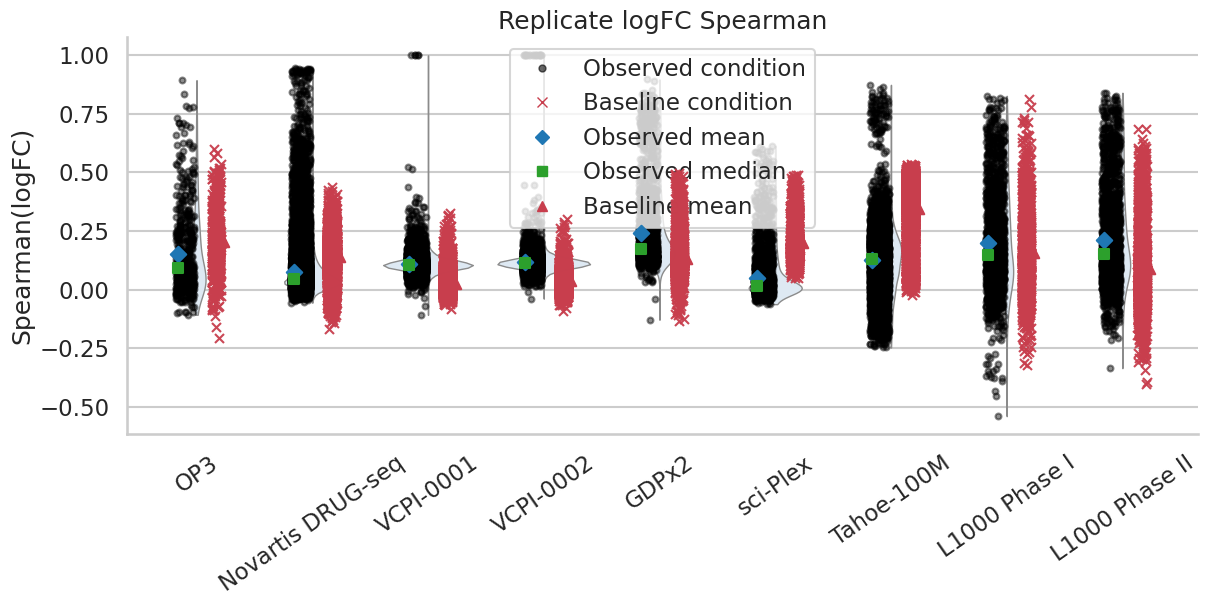

Saved plot to results/replicate_signature_similarity_sep_rep/replicate_signature_logfc_violin.pdf


,dataset_name,dataset_label,n_conditions,observed_mean,observed_median,baseline_mean,baseline_median,n_conditions_with_baseline
0,op3,OP3,541,0.151550,0.093585,0.206908,0.186769,541
1,novartis_batch_1000,Novartis DRUG-seq,15276,0.074512,0.043047,0.143105,0.142820,15276
2,vcpi_0001,VCPI-0001,13283,0.107598,0.105166,0.029949,0.027303,13283
3,vcpi_0002,VCPI-0002,8825,0.115519,0.111892,0.040811,0.039856,8825
4,gdpx2,GDPx2,2064,0.242817,0.173618,0.132793,0.109674,2064
5,sciplex,sci-Plex,2224,0.049556,0.014606,0.201016,0.183105,2224
6,tahoe,Tahoe-100M,7226,0.124576,0.130953,0.347681,0.394491,7226
7,l1000_phase1,L1000 Phase I,1504,0.196530,0.145346,0.158752,0.141680,1424
8,l1000_phase2,L1000 Phase II,1921,0.212848,0.153443,0.093480,0.058898,1918


In [3]:
signature_summary = plot_violin_with_baseline(
    condition_metric_summary,
    observed_col='mean_replicate_spearman_logfc',
    baseline_col='mean_replicate_baseline_spearman_logfc',
    title='Replicate logFC Spearman',
    ylabel='Spearman(logFC)',
    pdf_name='replicate_signature_logfc_violin.pdf',
)

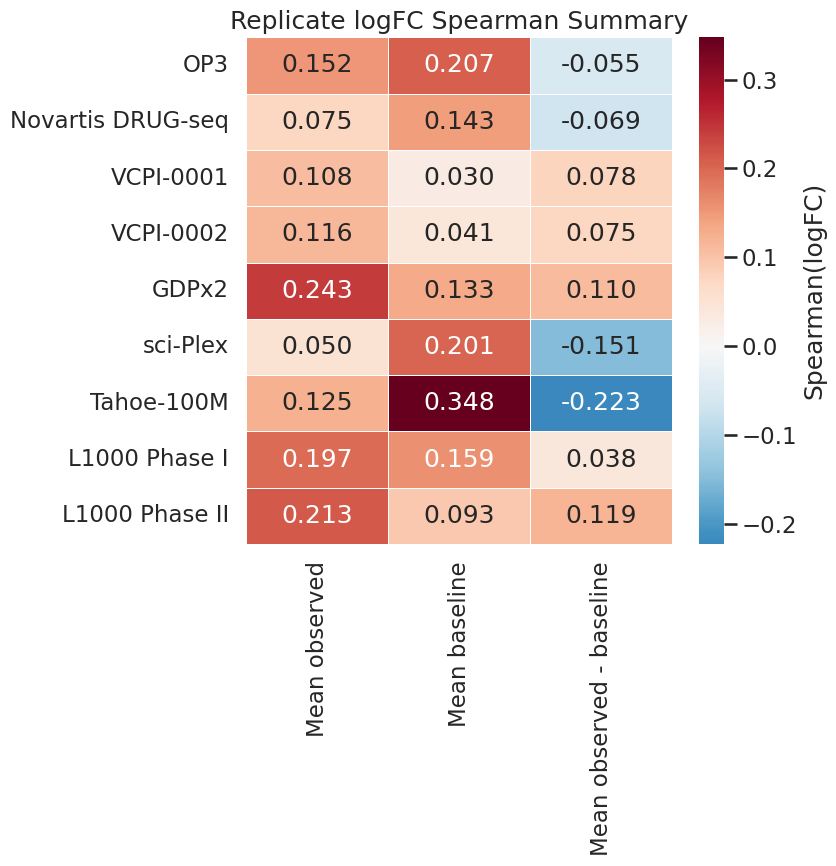

Saved heatmap to results/replicate_signature_similarity_sep_rep/replicate_signature_logfc_heatmap.pdf


,Mean observed,Mean baseline,Mean observed - baseline
Dataset,,,
OP3,0.151550,0.206908,-0.055358
Novartis DRUG-seq,0.074512,0.143105,-0.068593
VCPI-0001,0.107598,0.029949,0.077649
VCPI-0002,0.115519,0.040811,0.074708
GDPx2,0.242817,0.132793,0.110024
sci-Plex,0.049556,0.201016,-0.151460
Tahoe-100M,0.124576,0.347681,-0.223104
L1000 Phase I,0.196530,0.158752,0.037778
L1000 Phase II,0.212848,0.093480,0.119368


In [4]:
# Heatmap: signature logFC
signature_heatmap = plot_summary_heatmap(
    signature_summary,
    title='Replicate logFC Spearman Summary',
    value_label='Spearman(logFC)',
    pdf_name='replicate_signature_logfc_heatmap.pdf',
)